In [2]:
!pip install seaborn numpy pandas matplotlib scipy

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker


import pandas as pd
import seaborn as sns

EmptyDataError: No columns to parse from file

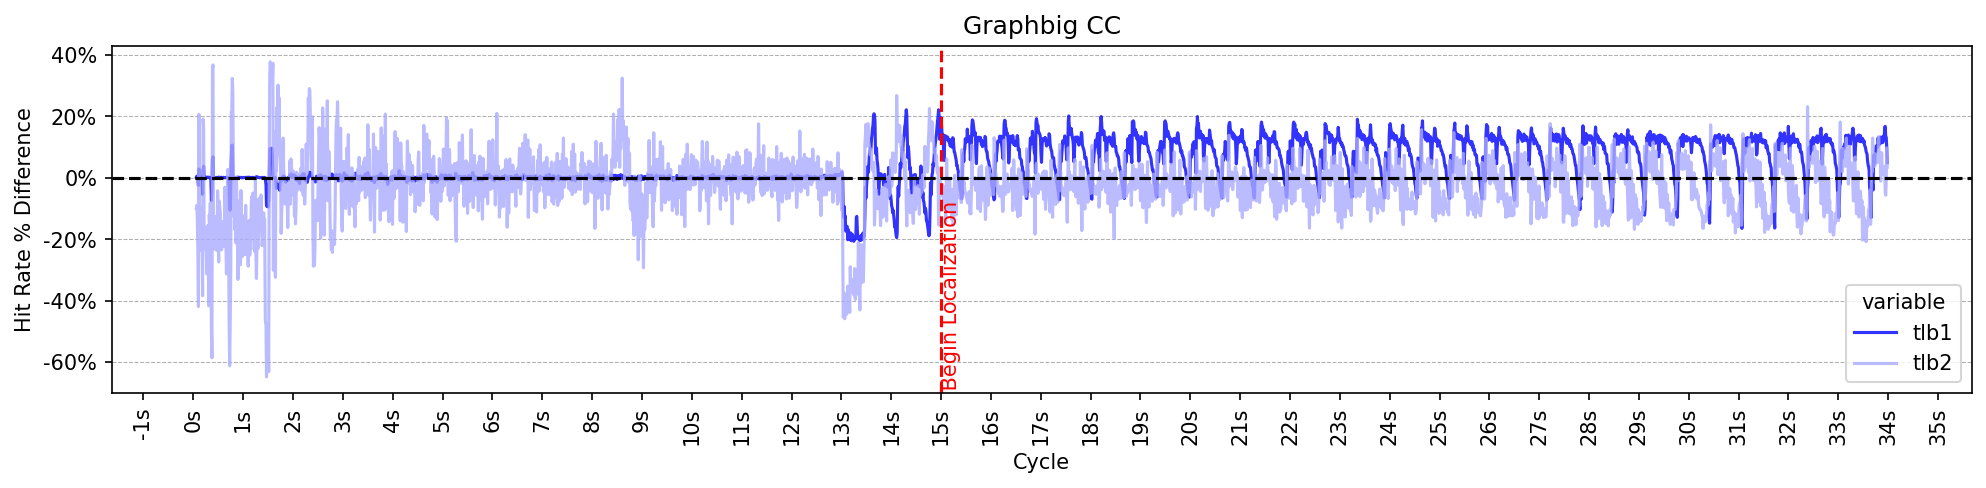

In [2]:
def plot_hitrate(path, title, locstart=None):
  df = pd.read_csv(path, header=0)
  # remove the column 'dcache1'
  df = df.drop(columns=['dcache1', 'dcache2', 'htlb1', 'htlb2'])

  df = df.melt(id_vars=['cycle'], var_name='variable', value_name='value')


  fig = plt.figure(figsize=(16, 3), dpi=150)
  sns.lineplot(df, x='cycle', y='value', hue='variable', palette={
    'tlb1': '#00F',
    'tlb2': '#aaF',

    'htlb1': '#F00',
    'htlb2': '#Faa',
    'dcache1': 'black',
    'dcache2': 'grey',
  })

  if locstart is not None:
    # draw a vertical line at locstart
    plt.axvline(x=locstart * 1e9, color='red', linestyle='--')
    # get the current lower bound of y axis
    y_min, y_max = plt.ylim()
    plt.text(locstart * 1e9, y_min, ' Begin Localization', rotation=90, color='red', fontsize=10)


  # set x axis ticks to every 1e9 cycles
  plt.gca().xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1e9))
  plt.gca().xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x / 1000 / 1000 / 1000:.0f}s"))
  # format y axis as percentage
  plt.gca().yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))
  # y axis grid
  plt.gca().yaxis.grid(True, which='major', linestyle='--', linewidth=0.5)
  plt.title(title)
  plt.xlabel('Cycle')
  plt.ylabel('Hit Rate')
  plt.xticks(rotation=90)


def plot_hitrate_diff(baseline, localizing, title, locstart):
  to_drop = ['dcache1', 'dcache2', 'htlb1', 'htlb2']
  dfb = pd.read_csv(baseline, header=0).drop(columns=to_drop)
  dfl = pd.read_csv(localizing, header=0).drop(columns=to_drop)

  dfl['tlb1'] = dfl['tlb1'] - dfb['tlb1']
  dfl['tlb2'] = dfl['tlb2'] - dfb['tlb2']

  df = dfl.melt(id_vars=['cycle'], var_name='variable', value_name='value')


  fig = plt.figure(figsize=(16, 3), dpi=150)
  sns.lineplot(df, x='cycle', y='value', hue='variable', alpha=0.8, palette={
    'tlb1': '#00F',
    'tlb2': '#aaF',

    'htlb1': '#F00',
    'htlb2': '#Faa',
    'dcache1': 'black',
    'dcache2': 'grey',
  })

  if locstart is not None:
    # draw a vertical line at locstart
    plt.axvline(x=locstart * 1e9, color='red', linestyle='--')
    # get the current lower bound of y axis
    y_min, y_max = plt.ylim()
    plt.text(locstart * 1e9, y_min, ' Begin Localization', rotation=90, color='red', fontsize=10)

  plt.axhline(y=0, color='black', linestyle='--')
    # get the current lower bound of y axis

  # set x axis ticks to every 1e9 cycles
  plt.gca().xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1e9))
  plt.gca().xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x / 1000 / 1000 / 1000:.0f}s"))
  # format y axis as percentage
  plt.gca().yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))
  # y axis grid
  plt.gca().yaxis.grid(True, which='major', linestyle='--', linewidth=0.5)
  plt.title(title)
  plt.xlabel('Cycle')
  plt.ylabel('Hit Rate % Difference')
  plt.xticks(rotation=90)
  pass


# plot_hitrate_diff("../hitrate_python_baseline.csv", "../hitrate_python_localize.csv", "Python Nbody", locstart=0.5)
plot_hitrate_diff("../hitrate_cc_baseline.csv", "../hitrate_cc_localize.csv", "Graphbig CC", locstart=15)

plot_hitrate_diff("../hitrate_cc_baseline.csv", "../hitrate.csv", "Graphbig CC", locstart=None)
plot_hitrate('../hitrate.csv', "GraphBIG CC - Localize (relocalize on)")
plot_hitrate('../hitrate_cc_baseline.csv', "GraphBIG CC - Baseline")
# plot_hitrate('../hitrate_cc_localize.csv', "GraphBIG CC Hitrate per 10ms window - Localizing", locstart=15)

effective seconds: nans


ValueError: Could not interpret value `dcache1` for `y`. An entry with this name does not appear in `data`.

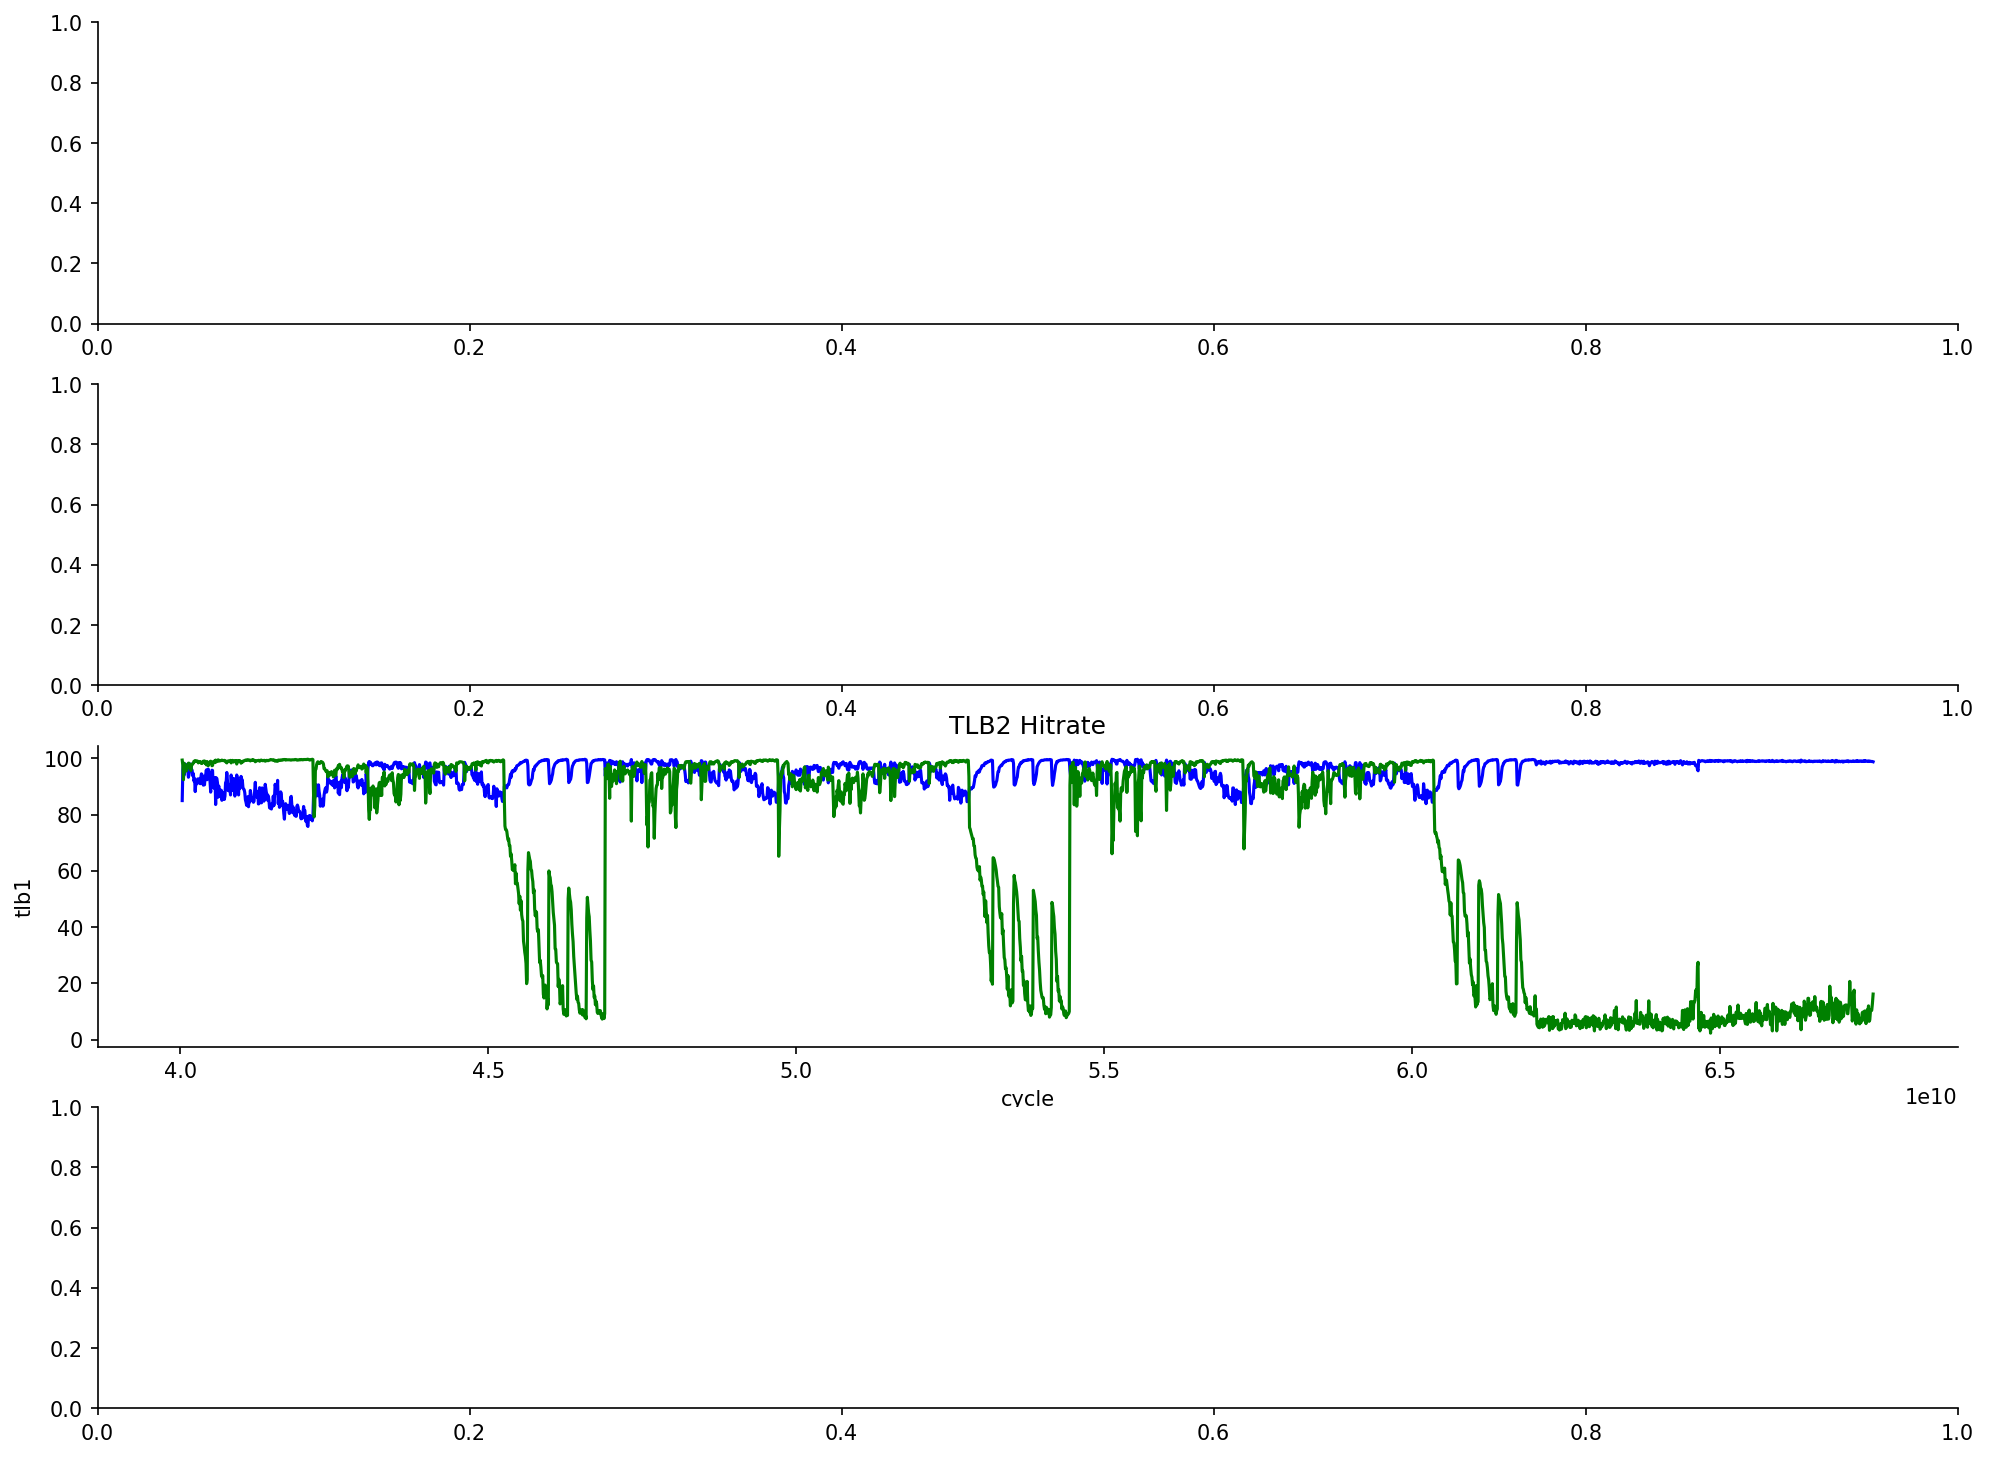

In [3]:
def plot_frag(run_name, marks = {}):
  frag_file = f"../htlb_sim/results/{run_name}/frag.csv"
  hitrate_file = f"../htlb_sim/results/{run_name}/hitrate.csv"
  df = pd.read_csv(frag_file)

  # break the dataframe into two dataframes. One where the `id` contains `Locality` and one where it does not
  df_locality = df[df['id'].str.contains('Locality')]
  df_non_locality = df[~df['id'].str.contains('Locality')]
  # reformat the id column to be the integer after the - char
  df_locality['id'] = df_locality['id'].str.split('-').str[1].astype(int)
  df_non_locality['id'] = df_non_locality['id'].str.split('-').str[1].astype(int)
  
  time_min = df['cycle'].min()
  time_max = df['cycle'].max()
  print(f'effective seconds: {(time_max - time_min) / 1e9:.4f}s')

  palette = {}
  # for each unique value in df['id']
  for i, id in enumerate(df['id'].unique()):
    if 'Locality' in id:
      palette[id] = '#000'
    else:
      palette[id] = '#88f'

  # make two figures on top of eachother

  fig, axs = plt.subplots(4, 1, figsize=(16, 12), dpi=150)
  for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

  bits = [
    (axs[0], 'SizedPages', df_non_locality, 'viridis'), 
    (axs[1], 'LocalityPages', df_locality, 'rocket')
  ]



  for ax, title, df, palette in bits:
    if len(df) == 0:
      continue
    g = sns.lineplot(df, x='cycle', y='frag', hue='id', alpha=0.75, palette=palette, ax=ax)
    # set the title
    ax.set_title(title)
    # set the y axis to be between 0 and 1
    ax.set_ylim(0, 1)
    g.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x / 1000 / 1000 / 1000:.0f}s"))
    ax.set_xlabel(None)
    g.yaxis.grid(True, which='major', linestyle='--', linewidth=0.5)

  df = pd.read_csv(hitrate_file)
  bits = [
    ('tlb1', 'TLB1 Hitrate', 'blue'),
    ('tlb2', 'TLB2 Hitrate', 'green'),
    ('dcache1', 'D$ Hitrate', 'red'),
  ]
  for col, title, color in bits:
    g = sns.lineplot(df, x='cycle', y=col, color=color, alpha=1.0, ax=axs[2])
    g.set_title(title)
  
  # make a legend from bits
  handles = []
  for col, title, color in bits:
    handles.append(plt.Line2D([0], [0], color=color, lw=3, label=title))
  axs[2].legend(handles=handles, loc='upper left')

  axs[2].set_title("Cache Hitrate")
  axs[2].set_ylim(0, 100)
  axs[2].set_xlabel(None)
  axs[2].set_ylabel('Cache hit rate %')
  g.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x / 1000 / 1000 / 1000:.0f}s"))
  g.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))
  g.yaxis.grid(True, which='major', linestyle='--', linewidth=0.5)



  for ax in axs:
    ax.set_xlim(time_min, time_max)
  for mark in marks:
    loc = marks[mark]
    x_min, x_max = axs[2].get_xlim()
    if loc * 1e9 > x_max:
      continue
    axs[2].axvline(x=loc * 1e9, color='black', linestyle='--')
    # get the current lower bound of y axis
    y_min, y_max = axs[2].get_ylim()
    axs[2].text(loc * 1e9, (y_max + y_min) / 7, f' {mark}', rotation=0, color='black', fontsize=10)

  print(df['mpki'].describe())
  g = sns.lineplot(df, x='cycle', y='mpki', color='black', alpha=0.5, ax=axs[3])
  g.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x / 1000 / 1000 / 1000:.0f}s"))

  plt.savefig(f"../htlb_sim/results/{run_name}/res.pdf", dpi=100)


marks = {}
# marks['begin'] = 40
# marks['iter 0'] = 42596179277 / 1e9
# marks['iter 1'] = 71106022976 / 1e9
# marks['iter 2'] = 99536057157 / 1e9
# plot_frag('cc_loc', marks = marks)
plot_frag('kcore_loc_fast', marks = marks)

In [5]:
def plot_hitrates(runs, marks):
  run_count = len(runs)
  fig, axs = plt.subplots(len(runs), 1, squeeze=False, figsize=(16, 3 * run_count), dpi=150)

  starts = []
  ends = []


  rightaxs = [] # [(ax, max)]



  for m in marks:
    ends.append(marks[m] * 1e9)

  # axs = axs[0]
  for (run, run_title), ax in zip(runs, axs):
    ax = ax[0]
    hitrate_file = f"../htlb_sim/results/{run}/hitrate.csv"



    try:
      df = pd.read_csv(hitrate_file)
    except FileNotFoundError:
      print(f"File {hitrate_file} not found")
      continue
    start = df['cycle'].min()
    end = df['cycle'].max()

    # if tlb1 is not in the data, compute it
    if 'tlb1' not in df.columns:
      df['tlb1'] = df['l1hit'] / (df['l1hit'] + df['l1miss']) * 100
      df['tlb2'] = df['l2hit'] / (df['l2hit'] + df['l2miss']) * 100
    starts.append(start)
    ends.append(end)

    bits = [
      ('tlb1', 'TLB1 Hitrate', 'blue'),
      ('tlb2', 'TLB2 Hitrate', 'green'),
      # ('dcache1', 'D$ Hitrate', 'red'),
    ]
    df['time'] = pd.to_datetime(df['cycle'], unit='ns')
    # print(df)
    for col, title, color in bits:
      g = sns.lineplot(df, x='cycle', y=col, color=color, alpha=0.2, ax=ax)
      g.set_title(title)
      df[f'{col}_rolling'] = df[col].rolling(window=100).mean()
      g = sns.lineplot(df, x='cycle', y=f'{col}_rolling', color=color, alpha=1, ax=ax)
    
    # make a legend from bits
    handles = []
    for col, title, color in bits:
      handles.append(plt.Line2D([0], [0], color=color, lw=3, label=title))
    ax.legend(handles=handles)


    l1_avg = df['tlb1'].mean()
    l2_avg = df['tlb2'].mean()
    ax.set_title(f'{run_title} - l1/l2 = {l1_avg:.2f}%/{l2_avg:.2f}%')
    ax.set_ylim(0, 100)
    ax.set_xlabel(None)
    ax.set_ylabel('Cache hit rate %')


    g.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x / 1000 / 1000 / 1000:.0f}s"))
    g.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))
    g.yaxis.grid(True, which='major', linestyle='--', linewidth=0.5)

    if 'l1hit' in df.columns:
      rax = ax.twinx()
      df['l1acc'] = df['l1hit'] + df['l1miss']
      df['l2acc'] = df['l2hit'] + df['l2miss']
      cpi = 8.7
      df['insts'] = df['cycle'] / cpi
      df['mpki1'] = df['l1miss'] / df['insts'] * 1000
      df['mpki2'] = df['l2miss'] / df['insts'] * 1000


      # g = sns.lineplot(df, x='cycle', y='l1acc', color='black', alpha=0.4, ax=rax)
      # g = sns.lineplot(df, x='cycle', y='l2acc', color='black', alpha=0.2, ax=rax)
      sns.lineplot(df, x='cycle', y='mpki1', color='black', alpha=0.4, ax=rax)
      sns.lineplot(df, x='cycle', y='mpki2', color='black', alpha=0.2, ax=rax)

      rightaxs.append((rax, max(df['mpki1'].max(), df['mpki2'].max())))

      # rax.set_ylim(0, None)


    for mark in marks:
      loc = marks[mark]
      ax.axvline(x=loc * 1e9, color='black', linestyle='--')
      # ax.axvline(x=loc * 1e9 - dump_interval, color='black', linestyle='-')
      # get the current lower bound of y axis
      y_min, y_max = ax.get_ylim()
      ax.text(loc * 1e9, (y_max + y_min) / 7, f' {mark}', rotation=0, color='black', fontsize=10)
  time_min = max(starts)
  time_max = max(ends)
  for ax in axs:
    ax[0].set_xlim(time_min, time_max)

  rightmax = max([ax[1] for ax in rightaxs])
  for ax, m in rightaxs:
    ax.set_ylim(0, rightmax)



def extract_marks(uartlog):
  marks = {}

  with open(uartlog, 'r') as f:
    for line in f:
      # if the line starts with YUKON_TIMESTAMP
      if line.startswith("YUKON_TIMESTAMP"):
        # split the line by space
        parts = line.strip().split(',')
        marks[parts[1]] = int(parts[2]) / 1e9
        print(parts)
    return marks


# marks = {}
# # marks['begin'] = 40
# marks['iter 0'] = 42596179277 / 1e9
# marks['iter 1'] = 71106022976 / 1e9
# marks['iter 2'] = 99536057157 / 1e9

# plot_hitrates([
#   ('cc_nl', "No Localization"),
#   ('cc_loc', "Localization")], marks = marks)

['YUKON_TIMESTAMP', 'iter: 0', '41170318615']
['YUKON_TIMESTAMP', 'iter: 1', '65394968494']
['YUKON_TIMESTAMP', 'iter: 2', '89654306604']


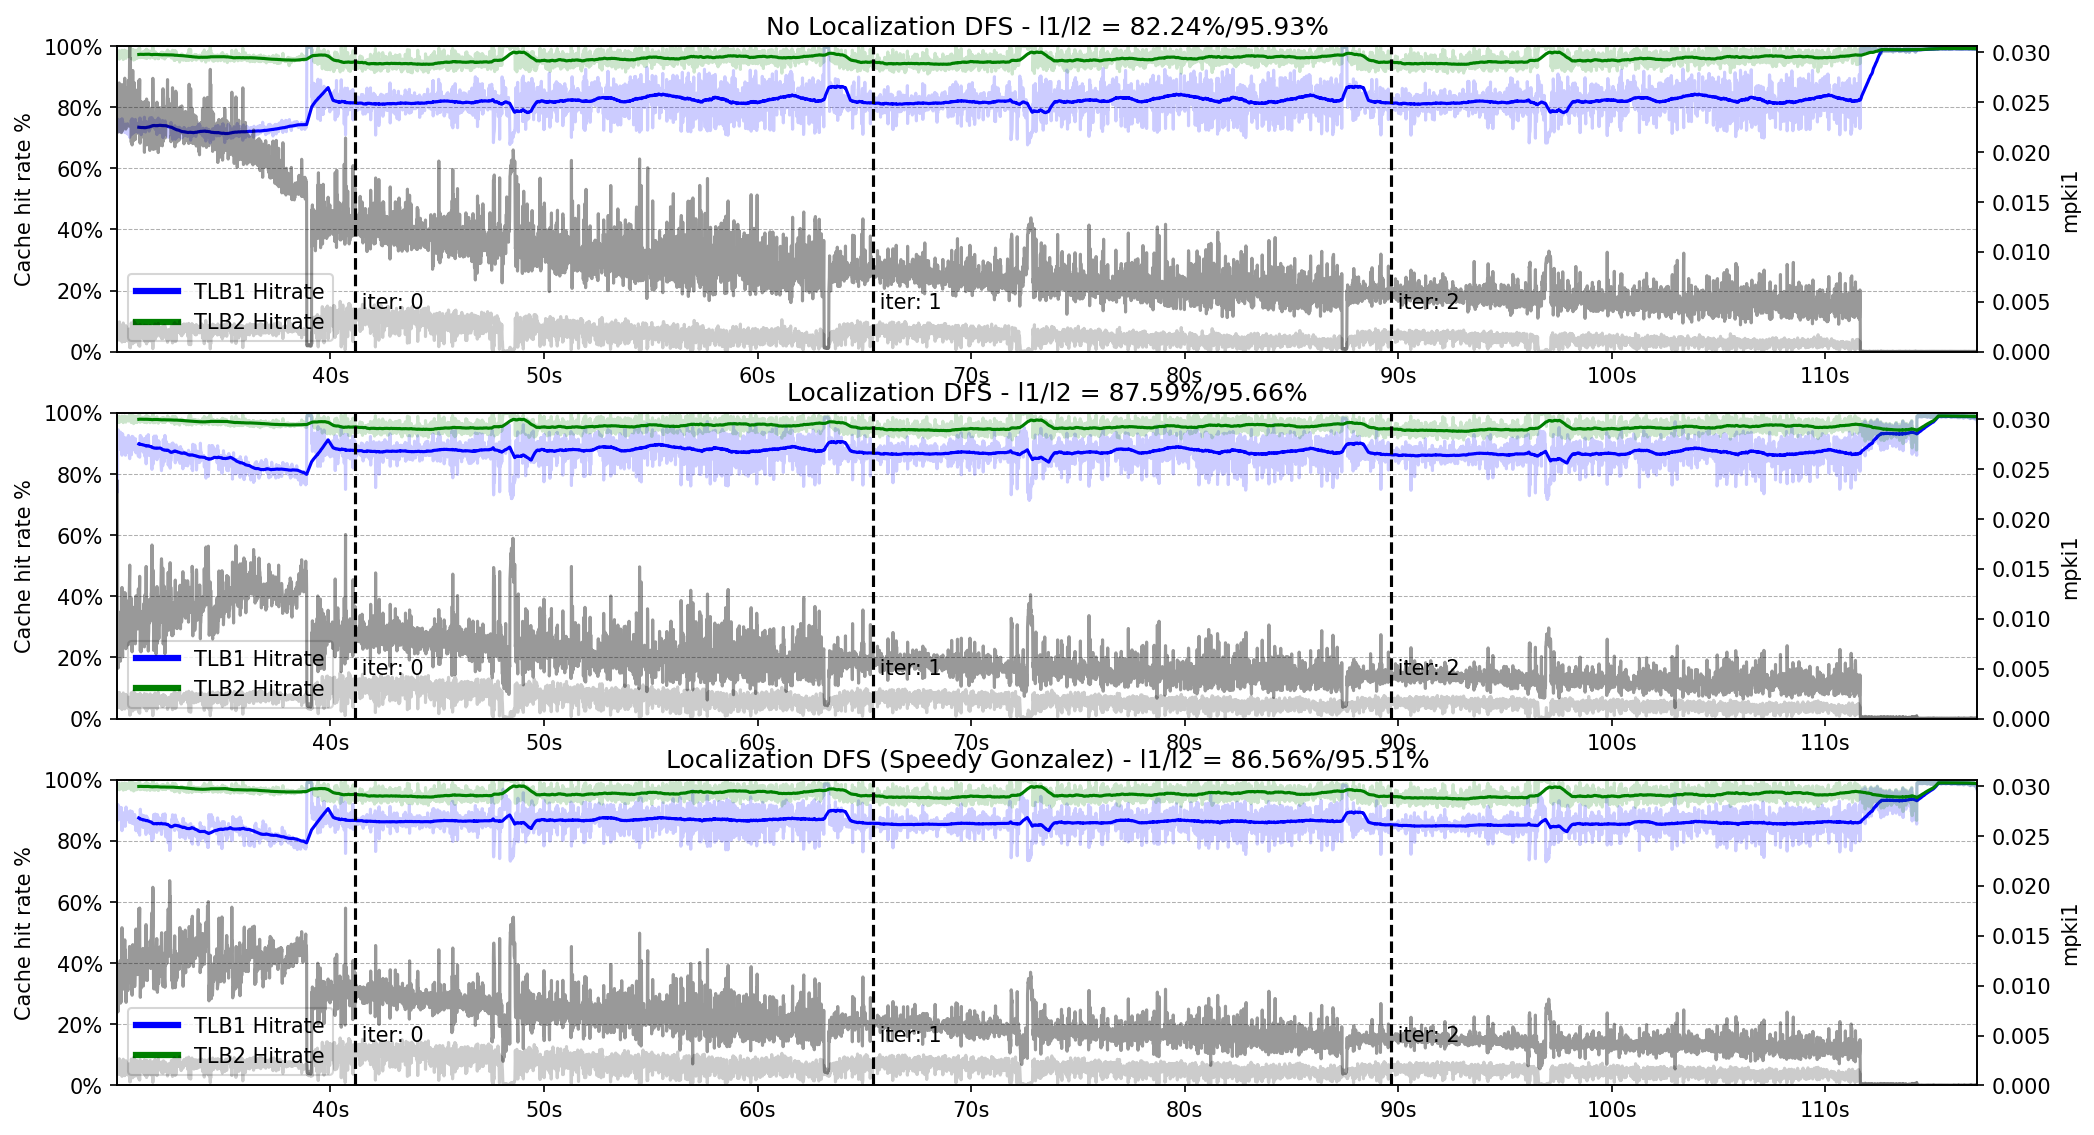

In [6]:
marks = extract_marks('/tank/project/yukon/logs/2025-04-08-112546_dfs/uartlog')
plot_hitrates([
  ('dfs_nl', 'No Localization DFS'),
  ('dfs_loc', 'Localization DFS'),
  ('dfs_loc_speedy', 'Localization DFS (Speedy Gonzalez)'),
], marks=marks)

['YUKON_TIMESTAMP', 'iter: 0', '44204456693']
['YUKON_TIMESTAMP', 'iter: 1', '51755309614']
['YUKON_TIMESTAMP', 'iter: 2', '59310503939']


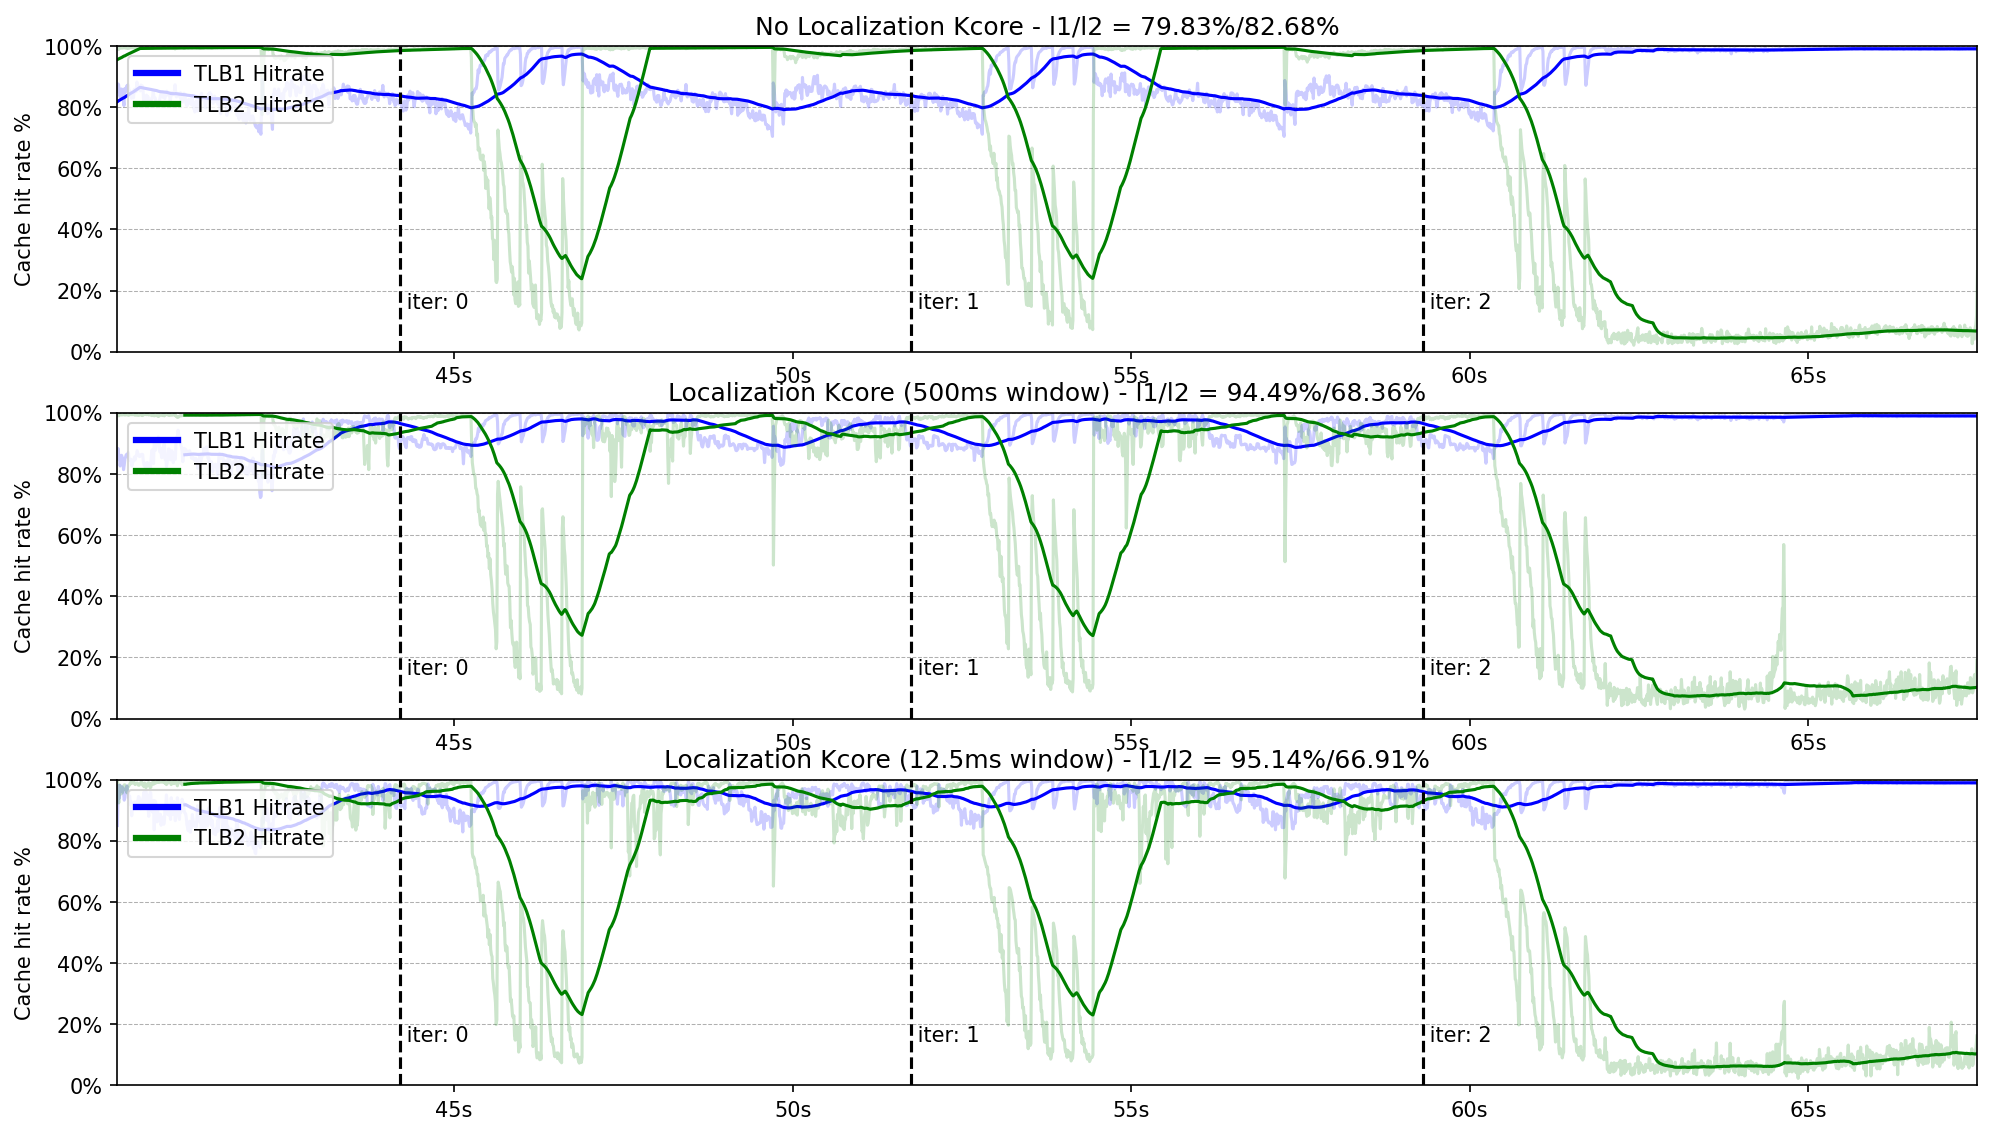

In [178]:
marks = extract_marks('/tank/project/yukon/logs/2025-04-08-122846_kcore/uartlog')
plot_hitrates([
  ('kcore_nl', 'No Localization Kcore'),
  ('kcore_loc', 'Localization Kcore (500ms window)'),
  ('kcore_loc_fast', 'Localization Kcore (12.5ms window)'),
], marks=marks)

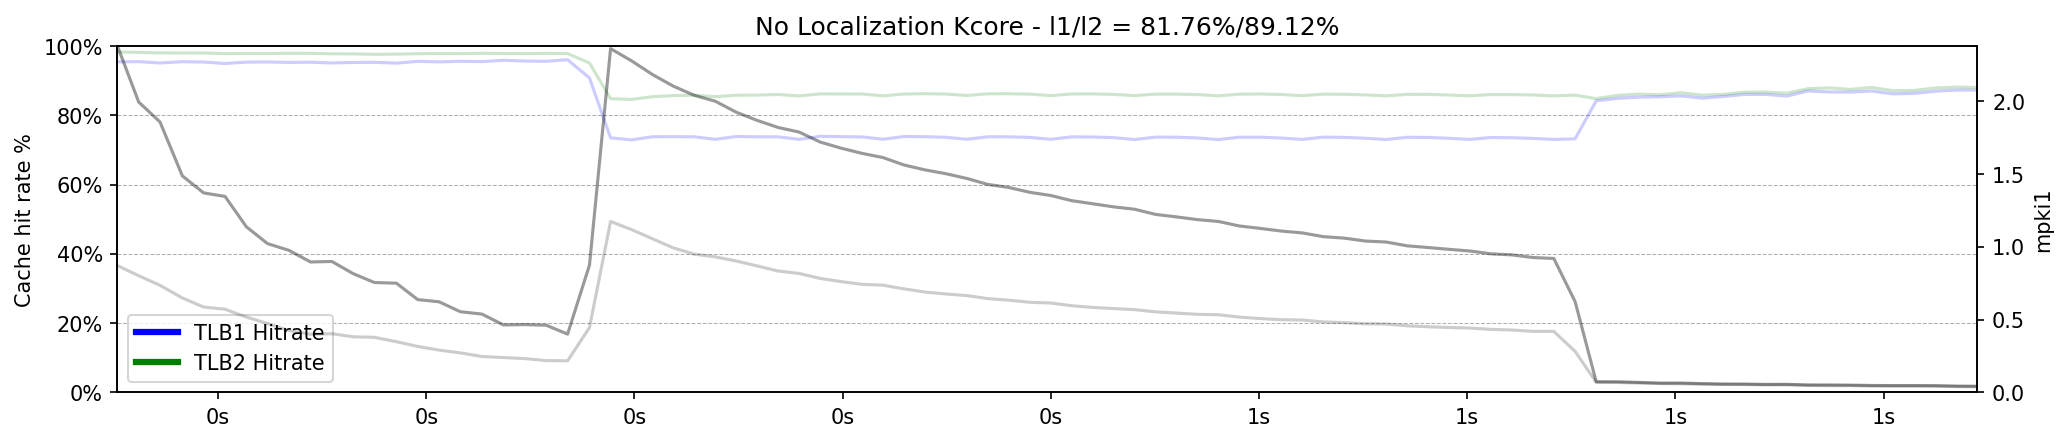

In [8]:
marks = {}
plot_hitrates([
  ('cc_test', 'No Localization Kcore'),
], marks=marks)